# 142 1단계 — 배율표 연도 홀드아웃

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다. 이 노트북은
`holdout.py`가 남긴 parquet을 **표·그림으로만** 다시 읽는다.

질문 하나다 — 146 §4-B가 인정한 순환 참조(배율표의 분자가 그 스냅샷 자체)를 끊으면
변환 층은 얼마나 맞히나.

    배율표 = A연도 스냅샷 ÷ A연도 재귀식 raw 평균   →   예측(B) = 배율표 × B연도 재귀식 raw 평균

식을 펴면 `예측(B) = 스냅샷(A) × raw평균(B)/raw평균(A)`다. 파이프라인이 전년도 표에 얹는 것은
**연도 변화율 하나**이고, 대조군 `copy_prev`는 그 변화율을 1로 두는 안이다.

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)
VALID = AI_ROOT / "data" / "CROWD" / "interim" / "validation"
PAIRS = [[2023, 2024], [2024, 2025]]
METHODS = ["pipeline", "copy_prev", "scale_only", "scale_const"]

metrics = pd.concat(
    [pd.read_parquet(VALID / f"calibration_holdout_{a}_{b}.parquet") for a, b in PAIRS],
    ignore_index=True,
)
cells = {
    (a, b): pd.read_parquet(VALID / f"calibration_holdout_cells_{a}_{b}.parquet") for a, b in PAIRS
}
print({k: len(v) for k, v in cells.items()})
metrics.head()

{(2023, 2024): 59728, (2024, 2025): 61421}


,method,axis,group,n,mae,rmse,corr,grade_agree_%,fit_year,eval_year
0,pipeline,전체,전체,59728,2.149812,3.839575,0.980330,96.795473,2023,2024
1,pipeline,방향,내선,5547,2.019888,2.862250,0.989586,95.637281,2023,2024
2,pipeline,방향,상선,23965,2.240884,4.077495,0.976919,96.924682,2023,2024
3,pipeline,방향,외선,5635,2.119167,3.278441,0.986708,96.024845,2023,2024
4,pipeline,방향,하선,24581,2.097367,3.911470,0.978787,97.107522,2023,2024


## 1. 전체 — 네 안 비교

`pipeline`(셀별 배율) · `copy_prev`(전년도 표 복사) · `scale_only`·`scale_const`
(방향×요일유형×30분당 계수 1~2개짜리 거친 적합, 146 §4-C와 같은 형태).

In [2]:
total = (
    metrics[metrics["axis"] == "전체"]
    .set_index(["fit_year", "eval_year", "method"])
    .loc[:, ["n", "mae", "rmse", "corr", "grade_agree_%"]]
)
total.round(3)

n    mae    rmse   corr  grade_agree_%
fit_year eval_year method                                                 
2023     2024      pipeline     59728  2.150   3.840  0.980         96.795
                   copy_prev    59728  2.462   4.105  0.980         96.338
                   scale_only   59728  9.155  13.525  0.772         89.971
                   scale_const  59728  8.051  11.321  0.808         90.581
2024     2025      pipeline     61421  1.540   3.644  0.984         97.778
                   copy_prev    61421  1.264   2.477  0.992         98.178
                   scale_only   61421  9.005  13.349  0.783         89.585
                   scale_const  61421  7.992  11.200  0.822         90.500

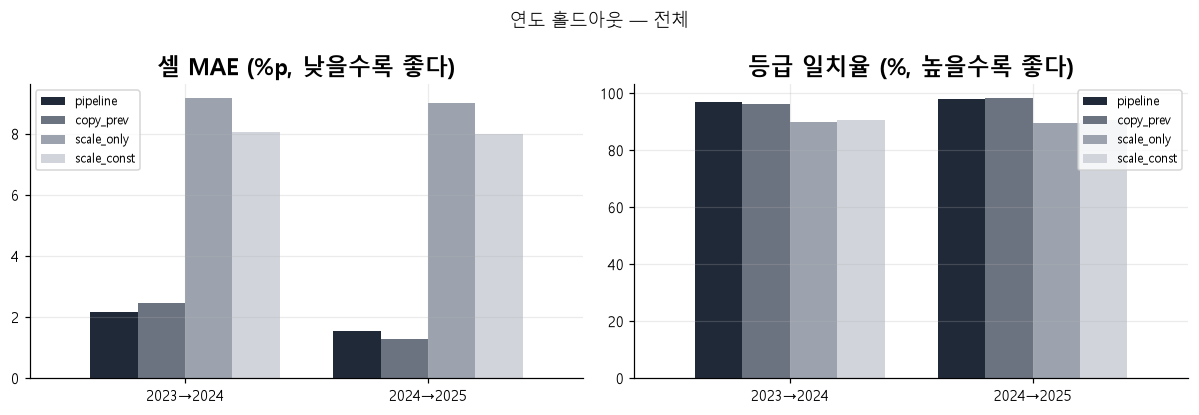

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (value, label) in zip(axes, [("mae", "셀 MAE (%p, 낮을수록 좋다)"), ("grade_agree_%", "등급 일치율 (%, 높을수록 좋다)")]):
    piv = (
        metrics[metrics["axis"] == "전체"]
        .assign(pair=lambda d: d["fit_year"].astype(str) + "→" + d["eval_year"].astype(str))
        .pivot_table(index="pair", columns="method", values=value)
        .reindex(columns=METHODS)
    )
    piv.plot.bar(ax=ax, rot=0, width=0.78, color=figstyle.PALETTE_NEUTRAL[: len(METHODS)])
    ax.set_title(label)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
fig.suptitle("연도 홀드아웃 — 전체", fontsize=12)
fig.tight_layout()

## 2. 파이프라인 vs 전년도 표 복사 — 슬라이스

두 쌍의 전체 부호가 반대다(2023→2024 파이프라인 우세, 2024→2025 열세). 어느 슬라이스가
그 차이를 만드는지 본다.

In [4]:
def slice_table(axis, value):
    sub = metrics[(metrics["axis"] == axis) & (metrics["method"].isin(["pipeline", "copy_prev"]))]
    piv = sub.pivot_table(index="group", columns=["fit_year", "method"], values=value)
    for a, b in PAIRS:
        piv[(a, "Δ")] = piv[(a, "pipeline")] - piv[(a, "copy_prev")]
    return piv.sort_index(axis=1).round(3)


slice_table("호선", "mae")

fit_year      2023                      2024                
method   copy_prev pipeline      Δ copy_prev pipeline      Δ
group                                                       
1호선          2.552    2.400 -0.151     1.060    4.219  3.158
2호선          2.304    2.070 -0.235     1.898    1.595 -0.303
3호선          2.153    1.713 -0.440     1.012    1.348  0.336
4호선          2.178    1.962 -0.216     1.154    1.262  0.109
5호선          2.672    2.289 -0.382     1.251    1.284  0.033
6호선          2.330    2.141 -0.189     1.163    1.182  0.020
7호선          1.820    1.631 -0.190     0.960    1.024  0.064
8호선          5.007    4.166 -0.841     1.169    3.404  2.236

In [5]:
slice_table("요일유형", "mae")

fit_year      2023                      2024                
method   copy_prev pipeline      Δ copy_prev pipeline      Δ
group                                                       
일요일          2.503    1.982 -0.521     1.121    1.367  0.246
토요일          3.370    2.824 -0.545     1.540    1.792  0.252
평일           1.545    1.660  0.114     1.132    1.461  0.328

In [6]:
slice_table("방향", "grade_agree_%")

fit_year      2023                      2024                
method   copy_prev pipeline      Δ copy_prev pipeline      Δ
group                                                       
내선          95.854   95.637 -0.216    96.599   97.401  0.802
상선          96.386   96.925  0.538    98.597   98.037 -0.560
외선          95.670   96.025  0.355    96.703   97.541  0.837
하선          96.554   97.108  0.553    98.461   97.662 -0.799

## 3. 원천 불연속이 범인이다

셀을 역 단위 **연간 승하차 총량 변화**로 3분류했다 — ±25%를 넘게 변한 역(개통·집계 정의 변화),
그 역과 같은 호선의 다른 역(재귀식은 노선을 따라 누적하므로 오차가 옆으로 번진다), 나머지.

In [7]:
cont = (
    metrics[(metrics["axis"] == "원천 연속성") & (metrics["method"].isin(["pipeline", "copy_prev"]))]
    .pivot_table(index=["fit_year", "group"], columns="method", values=["n", "mae", "grade_agree_%"])
)
cont.round(3)

grade_agree_%                mae                  n  \
method                    copy_prev pipeline copy_prev pipeline copy_prev   
fit_year group                                                              
2023     불연속 역              100.000  100.000     0.971    1.290     224.0   
         불연속 호선의 다른 역        96.684   97.326     2.227    1.989    5459.0   
         연속                  96.288   96.729     2.492    2.170   54045.0   
2024     불연속 역               98.491   83.405     2.175   10.859     464.0   
         불연속 호선의 다른 역        98.463   97.189     1.188    1.857   18603.0   
         연속                  98.050   98.194     1.288    1.298   42354.0   

                                
method                pipeline  
fit_year group                  
2023     불연속 역           224.0  
         불연속 호선의 다른 역   5459.0  
         연속            54045.0  
2024     불연속 역           464.0  
         불연속 호선의 다른 역  18603.0  
         연속            42354.0

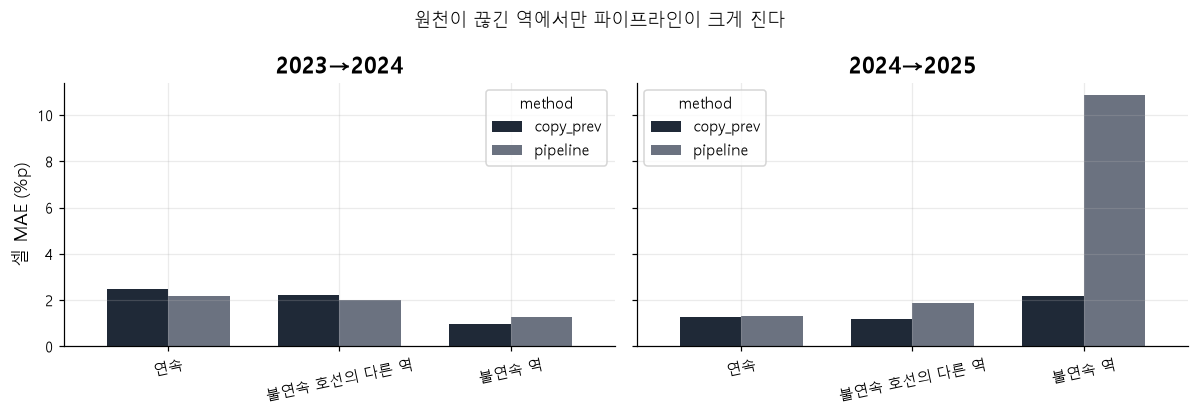

In [8]:
fig, axes = plt.subplots(1, len(PAIRS), figsize=(11, 3.8), sharey=True)
order = ["연속", "불연속 호선의 다른 역", "불연속 역"]
for ax, (a, b) in zip(np.atleast_1d(axes), PAIRS):
    sub = metrics[
        (metrics["axis"] == "원천 연속성")
        & (metrics["fit_year"] == a)
        & (metrics["method"].isin(["pipeline", "copy_prev"]))
    ]
    piv = sub.pivot_table(index="group", columns="method", values="mae").reindex(order)
    piv.plot.bar(ax=ax, rot=12, width=0.72, color=figstyle.PALETTE_NEUTRAL[:2])
    ax.set_title(f"{a}→{b}")
    ax.set_xlabel("")
    ax.set_ylabel("셀 MAE (%p)")
fig.suptitle("원천이 끊긴 역에서만 파이프라인이 크게 진다", fontsize=12)
fig.tight_layout()

In [9]:
top = cells[(2024, 2025)].assign(
    err=lambda d: (d["pred_pipeline"] - d["truth"]).abs(),
    변화율=lambda d: d["raw_eval"] / d["raw_fit"],
).nlargest(10, "err")
top[
    [
        "line",
        "station_no",
        "direction",
        "day_type",
        "time_slot_30min",
        "truth",
        "snap_fit",
        "변화율",
        "pred_pipeline",
        "err",
    ]
].round(2)

,line,station_no,direction,day_type,time_slot_30min,truth,snap_fit,변화율,pred_pipeline,err
8364,8호선,2810,하선,평일,08:00,83.3,70.9,3.10,219.96,136.66
41440,8호선,2811,상선,평일,18:30,58.4,58.1,2.98,173.34,114.94
6789,8호선,2810,하선,평일,07:30,68.8,60.4,3.02,182.29,113.49
9939,8호선,2810,하선,평일,08:30,59.7,51.8,3.10,160.71,101.01
39865,8호선,2811,상선,평일,18:00,55.0,48.7,2.98,145.29,90.29
5214,8호선,2810,하선,평일,07:00,49.2,45.2,3.02,136.42,87.22
11514,8호선,2810,하선,평일,09:00,50.8,45.6,2.95,134.40,83.60
43015,8호선,2811,상선,평일,19:00,49.7,43.0,3.08,132.25,82.55
3639,8호선,2810,하선,평일,06:30,38.5,35.1,3.11,109.28,70.78
38290,8호선,2811,상선,평일,17:30,46.5,39.5,2.96,116.80,70.30


## 4. 예측–정답 산점도

`pipeline`이 정답(그 해 스냅샷)을 얼마나 따라가는지. 붉은 점이 원천 불연속 역이다.

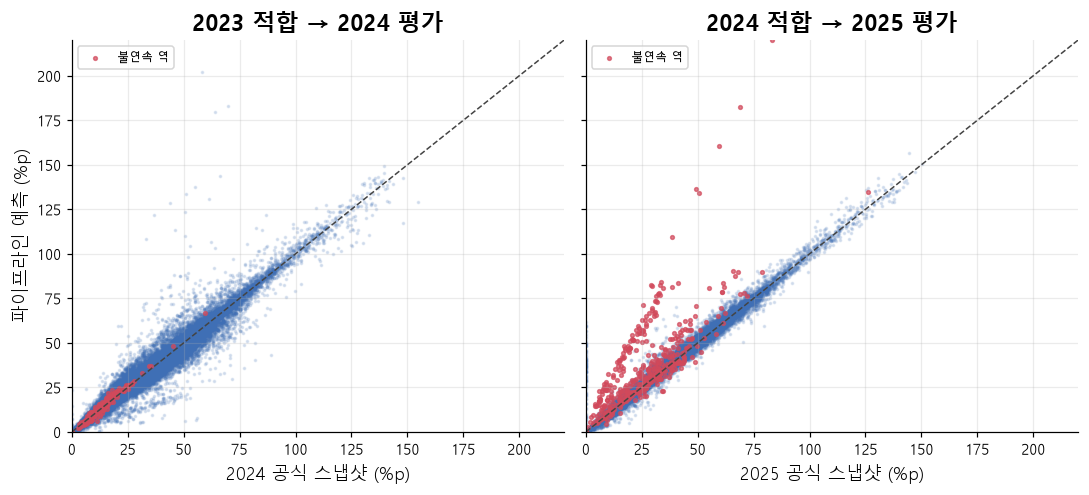

In [10]:
fig, axes = plt.subplots(1, len(PAIRS), figsize=(10, 4.6), sharex=True, sharey=True)
for ax, (a, b) in zip(np.atleast_1d(axes), PAIRS):
    c = cells[(a, b)]
    ok = c["source_continuity"] == "연속"
    ax.scatter(c.loc[ok, "truth"], c.loc[ok, "pred_pipeline"], s=2, alpha=0.15, color="#3f6fb5")
    ax.scatter(c.loc[~ok & (c["source_continuity"] == "불연속 역"), "truth"],
               c.loc[~ok & (c["source_continuity"] == "불연속 역"), "pred_pipeline"],
               s=6, alpha=0.7, color="#d1495b", label="불연속 역")
    lim = [0, 220]
    ax.plot(lim, lim, lw=1, color="#444", ls="--")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_title(f"{a} 적합 → {b} 평가")
    ax.set_xlabel(f"{b} 공식 스냅샷 (%p)")
    ax.legend(fontsize=8, loc="upper left")
np.atleast_1d(axes)[0].set_ylabel("파이프라인 예측 (%p)")
fig.tight_layout()

## 5. 읽은 것

판정 문장은 [`RESULTS.md`](./RESULTS.md) 5절이 원본이다. 그림에서 바로 보이는 것만 적으면:

1. **거친 적합(`scale_only`·`scale_const`)은 셀별 배율의 5~6배 나쁘다.** 역 단위 자유도가
   배율표의 핵심이고, 배율표를 단순화하자는 안(199)은 이 수치를 기준선으로 삼아야 한다.
   상수항은 두 쌍 모두 스케일-only를 이긴다 — 146 §4-C의 "경계 유입이 실재한다"가 전 호선에서 재확인된다.
2. **연속 구간에서는 파이프라인이 근소 우세**(등급 +0.14 / +0.44%p)이고, 전체 부호를 뒤집는 것은
   0.76%에 불과한 **불연속 역 464셀**이다(8호선 암사역사공원 2024-08 개통, 1호선 서울역 +32%).
3. **공식 스냅샷은 해마다 거의 안 움직인다**(`copy_prev` MAE 1.26~2.46%p). 이길 여지 자체가 작다 —
   그래서 판정은 "이기지 못함 → 공식표 재현 수준으로 서술"이다.
4. 산점도의 붉은 점은 전부 대각선 **위쪽**에 있다. 파이프라인이 승하차 증가를 그대로 밀어 올리는데
   공식표는 따라오지 않았다 — 141이 남긴 서울역 집계 정의 변화 의심과 같은 방향이다.